In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib import rcParams
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.ticker import NullFormatter
import matplotlib.font_manager as fm
from matplotlib.ticker import ScalarFormatter

def on_press(event):
    print("my position:", event.button, event.xdata, event.ydata)

fontsize = 8
fonttype = 'sans-serif'
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['figure.dpi'] = 150

if (fonttype == 'serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    mpl.rc('text.latex', preamble=r'\usepackage{amsmath, newtxtext, newtxmath}')
    plt.rcParams['font.family'] = 'serif'
elif (fonttype == 'sans-serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    plt.rcParams['font.family'] = 'sans-serif'
    latex_preamble = r"""
    \usepackage[T1]{fontenc}
    \usepackage{bm, amsmath, sansmathfonts}    

    \makeatletter
    \AtBeginDocument{
        \DeclareSymbolFont{sansextrabold}{T1}{cmss}{bx}{n}
        \DeclareMathSymbol{+}{\mathbin}{sansextrabold}{"2B}
        \DeclareMathSymbol{=}{\mathrel}{sansextrabold}{"3D}
        \DeclareMathSymbol{<}{\mathrel}{sansextrabold}{"3C}
        \DeclareMathSymbol{>}{\mathrel}{sansextrabold}{"3E}
        \DeclareMathSymbol{|}{\mathord}{sansextrabold}{"7C}
        \DeclareMathSymbol{/}{\mathord}{sansextrabold}{"2F}

        \DeclareSymbolFont{boldsanssymbols}{OMS}{cmsssy}{b}{n}
        \DeclareMathSymbol{-}{\mathbin}{boldsanssymbols}{"00}
        \DeclareMathSymbol{\times}{\mathbin}{boldsanssymbols}{"02}


        \DeclareMathSymbol{\oplus}{\mathbin}{boldsanssymbols}{"08}
        \DeclareMathSymbol{\otimes}{\mathbin}{boldsanssymbols}{"0A}
        \DeclareMathSymbol{\approx}{\mathrel}{boldsanssymbols}{"19}
        \DeclareMathSymbol{\perp}{\mathrel}{boldsanssymbols}{"3F}
        \DeclareMathSymbol{\sim}{\mathrel}{boldsanssymbols}{"18}
        \DeclareMathSymbol{\to}{\mathrel}{boldsanssymbols}{"21}
        \DeclareMathSymbol{\leftarrow}{\mathrel}{boldsanssymbols}{"20}
        \DeclareMathSymbol{\in}{\mathrel}{boldsanssymbols}{"32}

        \let\original@le\le
        \let\original@ge\ge
        \let\original@langle\langle
        \let\original@rangle\rangle

        \renewcommand{\le}{\bm{\original@le}}
        \renewcommand{\ge}{\bm{\original@ge}}
        \renewcommand{\langle}{\bm{\original@langle}}
        \renewcommand{\rangle}{\bm{\original@rangle}}
        \renewcommand{\|}{|\hspace{-1pt}|}
    }
    \makeatother

    \newcommand{\p}{\partial}
    \newcommand{\T}{^{\mathrm{T}}}
    \renewcommand{\vec}[1]{\boldsymbol{#1}}
    \newcommand{\bn}{\vec{\nabla}}
    \newcommand\ii{\mathrm{i}}
    \newcommand\ee{\mathrm{e}}
    \newcommand{\widebar}[1]{\mskip.5\thinmuskip\overline{\mskip-.5\thinmuskip {#1} \mskip-.5\thinmuskip}\mskip.5\thinmuskip}
    \newcommand{\ket}[1]{| #1 \rangle}
    \newcommand{\bra}[1]{\langle #1 |}
    """
    mpl.rc('text.latex', preamble=latex_preamble)

In [158]:
data_n = np.load("1d-n-effect.npz")

t1 = data_n["times"]

error_n5 = data_n["rel_l2_err_n5"]
error_n8 = data_n["rel_l2_err_n8"]
error_n11 = data_n["rel_l2_err_n11"]

eta_n5 = data_n["etan5"]
eta_n8 = data_n["etan8"]
eta_n11 = data_n["etan11"]

In [159]:
data_m = np.load("1d-m-effect.npz")

t2 = data_m["times"]

error_m3 = data_m["rel_l2_err_m3"]
error_m4 = data_m["rel_l2_err_m4"]
error_m5 = data_m["rel_l2_err_m5"]

eta_m3 = data_m["etam3"]
eta_m4 = data_m["etam4"]
eta_m5 = data_m["etam5"]

In [160]:
data_method = np.load("1d-differmethod-effect.npz")

t3 = data_method["times"]

ssfm = data_method["rel_l2_err_ssfm"]  
#fssfm = data_method["rel_l2_err_filtered_ssfm"] 
qssfm = data_method["rel_l2_err_filtered_qssfm"]
qssfm_with_norm = data_method["rel_l2_err_filtered_qssfm_with_norm"]


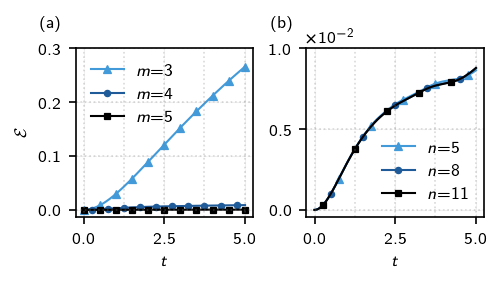

In [ ]:
fontsize = 8
width = 8.6 / 2.54
height = width * 0.6


light_blue = '#AFCDEA'
mid_blue   = "#429ad9"
dark_blue  = '#1F5A99'


def add_reference_lines(ax, h_values, v_values,
                        color='0.5', linestyle=':',
                        linewidth=0.8, alpha=0.3):

    for y in h_values:
        ax.axhline(y, linestyle=linestyle, linewidth=linewidth,
                   color=color, alpha=alpha)
    for x in v_values:
        ax.axvline(x, linestyle=linestyle, linewidth=linewidth,
                   color=color, alpha=alpha)


def style_axis(ax, xlabel, ylabel=None,
               xticks=None, yticks=None,
               label_fontsize=fontsize,
               tick_fontsize=fontsize,
               y_sci=False,
               sci_powerlimits=(-2, 2)):

    ax.grid(True, which='both',
            linestyle='--',
            linewidth=0.5,
            color='0.8',
            alpha=0.3)

    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=label_fontsize)

    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)

    ax.tick_params(axis='both', labelsize=tick_fontsize)


    if y_sci:
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits(sci_powerlimits)
        ax.yaxis.set_major_formatter(formatter)
        ax.ticklabel_format(axis='y', style='sci', scilimits=sci_powerlimits)
def add_panel_label(ax, label, x=-0.2, y=1.2, fontsize=8):

    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=fontsize,
        va='top', ha='left'
    )


def plot_lines(ax, x, line_specs):

    for spec in line_specs:
        ax.plot(
            x,
            spec['y'],
            color=spec.get('color', 'k'),
            linewidth=spec.get('linewidth', 1.0),
            linestyle=spec.get('linestyle', '-'),
            label=spec.get('label', None),
            marker=spec.get('marker', None),
            markersize=spec.get('markersize', None),
            markevery=spec.get('markevery', None),
            markerfacecolor=spec.get('markerfacecolor', None),
            markeredgecolor=spec.get('markeredgecolor', None),
            markeredgewidth=spec.get('markeredgewidth', None),
        )

def setup_panel(ax, x, line_specs, panel_label,
                xlabel=r"$t$", ylabel=None,
                xticks=None, yticks=None,
                hline_values=None, vline_values=None,
                legend=True,
                legend_kwargs=None,
                y_sci=False,
                sci_powerlimits=(-2, 2)):

    plot_lines(ax, x, line_specs)

    style_axis(
        ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xticks=xticks,
        yticks=yticks,
        y_sci=y_sci,
        sci_powerlimits=sci_powerlimits
    )

    if hline_values is not None or vline_values is not None:
        add_reference_lines(
            ax,
            h_values=[] if hline_values is None else hline_values,
            v_values=[] if vline_values is None else vline_values
        )

    if legend:
        if legend_kwargs is None:
            legend_kwargs = {}
        ax.legend(
            frameon=False,
            fontsize=fontsize,
            **legend_kwargs
        )

    add_panel_label(ax, panel_label)



panel_configs = [
    {
        "x": t1,
        "line_specs": [
            {"y": error_m3, "color": mid_blue, 'marker':'^' ,   "linewidth": 1, "label": r"$m$=3",
                "markersize": 4,
                "markevery": 50,  
                "markerfacecolor": mid_blue,
                "markeredgecolor": mid_blue,
                "markeredgewidth": 0.6},
            {"y": error_m4, "color": dark_blue, 'marker':'o',   "linewidth": 1, "label": r"$m$=4",
                             "markersize": 3,
                "markevery":(25,50) ,   
                "markerfacecolor": dark_blue,
                "markeredgecolor": dark_blue,
                "markeredgewidth": 0.6},
            {"y": error_m5, "color": 'black', 'marker':'s',  "linewidth": 1, "label": r"$m$=5",
                             "markersize": 3,
                "markevery": 50,   
                "markerfacecolor": 'black',
                "markeredgecolor": 'black',
                "markeredgewidth": 0.6},
        ],
        "panel_label": "(a)",
        "xlabel": r"$t$",
        "ylabel": r"$\mathcal{E}$",
        "xticks": np.linspace(0, 5, 3),
        "yticks": np.linspace(0, 0.3, 4),
        "hline_values": np.linspace(0, 0.3, 4),
        "vline_values": np.linspace(0, 5, 5),
        "legend": True,
    },
    {
        "x": t2,
        "line_specs": [
            {
                "y": error_n5,
                "color": mid_blue,
                "linewidth": 1,
                "label":  r"$n$=5",
                "marker": "^",
                "markersize": 4,
                "markevery":(75,100) ,   
                "markerfacecolor": mid_blue,
                "markeredgecolor": mid_blue,
                "markeredgewidth": 0.6
            },
            {
                "y": error_n8,
                "color": dark_blue,
                "linewidth": 1,
                #"linestyle": "none",
                "label": r"$n$=8",
                "marker": "o",
                "markersize": 3,
                "markevery": (50,100),  
                "markerfacecolor": dark_blue,
                "markeredgecolor": dark_blue,
                "markeredgewidth": 0.6
            },
            {
                "y": error_n11,
                "color": 'black',
                "linewidth": 1,
                #"linestyle": "none",
                "label": r"$n$=11",
                "marker": "s",
                "markersize": 3,
                "markevery": (25,100) ,
                "markerfacecolor": 'black',
                "markeredgecolor": 'black',
                "markeredgewidth": 0.6
            },
        ],
        "panel_label": "(b)",
        "xlabel": r"$t$",
        "ylabel": None,
        "xticks": np.linspace(0, 5, 3),
        "yticks": np.linspace(0, 0.01, 3),
        "hline_values": np.linspace(0, 0.01, 3),
        "vline_values": np.linspace(0, 5, 5),
        "legend": True,
        "y_sci": True,
        "sci_powerlimits": (-2, 2),
    },
]

def main():
    fig, axes = plt.subplots(1, 2, figsize=(width, height))

    for ax, cfg in zip(axes, panel_configs):
        setup_panel(
        ax=ax,
        x=cfg["x"],
        line_specs=cfg["line_specs"],
        panel_label=cfg["panel_label"],
        xlabel=cfg["xlabel"],
        ylabel=cfg["ylabel"],
        xticks=cfg["xticks"],
        yticks=cfg["yticks"],
        hline_values=cfg["hline_values"],
        vline_values=cfg["vline_values"],
        legend=cfg["legend"],
        legend_kwargs=cfg.get("legend_kwargs", None),
        y_sci=cfg.get("y_sci", False),
        sci_powerlimits=cfg.get("sci_powerlimits", (-2, 2)),
)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)

    plt.savefig("1D_error.svg", dpi=300,bbox_inches="tight", pad_inches=0.02)
    plt.savefig("1D_error.pdf", dpi=300,bbox_inches="tight", pad_inches=0.02)
    # plt.show()


if __name__ == "__main__":
    main()

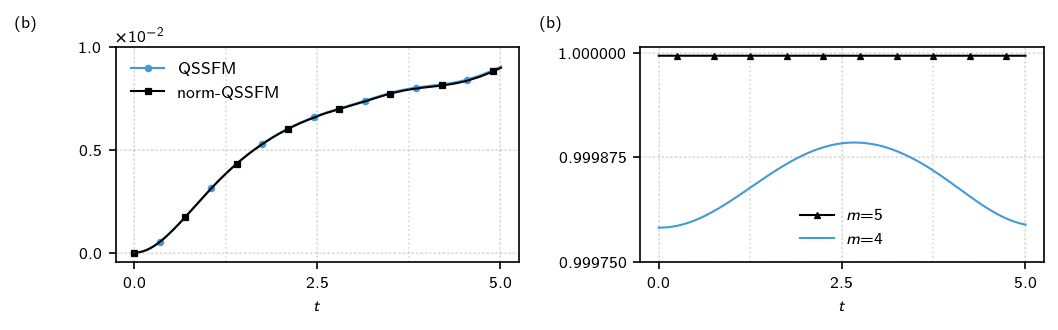

In [ ]:

fontsize = 8
width = 17.9 / 2.54
height = width * 0.325

light_blue = '#AFCDEA'
mid_blue   = "#429ad9"
dark_blue  = '#1F5A99'


def add_reference_lines(ax, h_values, v_values,
                        color='0.5', linestyle=':',
                        linewidth=0.8, alpha=0.3):

    for y in h_values:
        ax.axhline(y, linestyle=linestyle, linewidth=linewidth,
                   color=color, alpha=alpha)
    for x in v_values:
        ax.axvline(x, linestyle=linestyle, linewidth=linewidth,
                   color=color, alpha=alpha)


def style_axis(ax, xlabel, ylabel=None,
               xticks=None, yticks=None,
               label_fontsize=fontsize,
               tick_fontsize=fontsize,
               y_sci=False,
               sci_powerlimits=(-2, 2)):

    ax.grid(True, which='both',
            linestyle='--',
            linewidth=0.5,
            color='0.8',
            alpha=0.3)

    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=label_fontsize)

    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)

    ax.tick_params(axis='both', labelsize=tick_fontsize)


    if y_sci:
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits(sci_powerlimits)
        ax.yaxis.set_major_formatter(formatter)
        ax.ticklabel_format(axis='y', style='sci', scilimits=sci_powerlimits)
def add_panel_label(ax, label, x=-0.25, y=1.15, fontsize=8):

    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=fontsize,
        va='top', ha='left'
    )


def plot_lines(ax, x, line_specs):

    for spec in line_specs:
        ax.plot(
            x,
            spec['y'],
            color=spec.get('color', 'k'),
            linewidth=spec.get('linewidth', 1.0),
            linestyle=spec.get('linestyle', '-'),
            label=spec.get('label', None),
            marker=spec.get('marker', None),
            markersize=spec.get('markersize', None),
            markevery=spec.get('markevery', None),
            markerfacecolor=spec.get('markerfacecolor', None),
            markeredgecolor=spec.get('markeredgecolor', None),
            markeredgewidth=spec.get('markeredgewidth', None),
        )

def setup_panel(ax, x, line_specs, panel_label,
                xlabel=r"$t$", ylabel=None,
                xticks=None, yticks=None,
                hline_values=None, vline_values=None,
                legend=True,
                y_sci=False,
                sci_powerlimits=(-2, 2)):

    plot_lines(ax, x, line_specs)

    style_axis(
        ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xticks=xticks,
        yticks=yticks,
        y_sci=y_sci,
        sci_powerlimits=sci_powerlimits
    )

    if hline_values is not None or vline_values is not None:
        add_reference_lines(
            ax,
            h_values=[] if hline_values is None else hline_values,
            v_values=[] if vline_values is None else vline_values
        )

    if legend:
        ax.legend(frameon=False, fontsize=fontsize)

    add_panel_label(ax, panel_label)



panel_configs = [
    {
        "x": t3,
        "line_specs": [
            #{"y": ssfm,            "color": dark_blue,  "linewidth": 1, "label": "SSFM"},
            {"y": qssfm,           "color": mid_blue,  "linewidth": 1, "label": "QSSFM",
                "marker" :"o",
                "markersize": 3,
                "markevery":(35, 70),  
                "markerfacecolor": mid_blue,
                "markeredgecolor": mid_blue,
                "markeredgewidth": 0.6
                },
            {"y": qssfm_with_norm,
                "linewidth" : 1,
                "label": "norm-QSSFM",
                #"linestyle": "none",
                "marker": "s",
                "markersize": 3,
                "markevery": 70,
                "markerfacecolor": 'black',
                "markeredgecolor": 'black',
                "markeredgewidth": 0.6
            },
        ],
        "panel_label": "(b)",
        "xlabel": r"$t$",
        "ylabel": None,
        "xticks": np.linspace(0, 5, 3),
        "yticks": np.linspace(0, 0.01, 3),
        "hline_values": np.linspace(0, 0.01, 3),
        "vline_values": np.linspace(0, 5, 5),
        "legend": True,
            "legend_kwargs": {
        "loc": "upper left",
        "bbox_to_anchor": (0.46, 0.5),
        "handlelength": 1.2,
        "handletextpad": 0.4,
        "labelspacing": 0.2,
        "borderaxespad": 0.2,
        },
        "y_sci": True,
        "sci_powerlimits": (-2, 2),
    },
    {
        "x": t1,
        "line_specs": [
            {"y": eta_m5,
                "color": 'black',
                "linewidth": 1,
                "label": r"$m$=5",
                "marker": "^",
                "markersize": 3,
                "markevery": (25,50) ,
                "markerfacecolor": 'black',
                "markeredgecolor": 'black',
                "markeredgewidth": 0.6},
            {"y": eta_m4, "color": mid_blue,     "linewidth": 1, "label": r"$m$=4"},
        ],
        "panel_label": "(b)",
        "xlabel": r"$t$",
        "ylabel": None,
        "xticks": np.linspace(0, 5, 3),
        "yticks": np.linspace(0.99975, 1, 3),
        "hline_values": np.linspace(0.99975, 1, 3),
        "vline_values": np.linspace(0, 5, 5),
        "legend": True,
        #"y_sci": True,
        "sci_powerlimits": (-2, 2),
    },
]

def main():
    fig, axes = plt.subplots(1, 2, figsize=(width, height))

    for ax, cfg in zip(axes, panel_configs):
        setup_panel(
            ax=ax,
            x=cfg["x"],
            line_specs=cfg["line_specs"],
            panel_label=cfg["panel_label"],
            xlabel=cfg["xlabel"],
            ylabel=cfg["ylabel"],
            xticks=cfg["xticks"],
            yticks=cfg["yticks"],
            hline_values=cfg["hline_values"],
            vline_values=cfg["vline_values"],
            legend=cfg["legend"],
            y_sci=cfg.get("y_sci", True),
            sci_powerlimits=cfg.get("sci_powerlimits", (-2, 2)),
        )

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)

    #plt.savefig("1D_error.svg", dpi=300)
    # plt.show()


if __name__ == "__main__":
    main()

In [163]:
data_method = np.load("1d-differmethod-effect_n=3.npz")

t3 = data_method["times"]

ssfmn3 = data_method["rel_l2_err_ssfm"]  
#fssfm = data_method["rel_l2_err_filtered_ssfm"] 
qssfmn3 = data_method["rel_l2_err_filtered_qssfm"]
qssfm_with_normn3 = data_method["rel_l2_err_filtered_qssfm_with_norm"]

In [164]:
data_method = np.load("1d-differmethod-effect.npz")

t3 = data_method["times"]

ssfm = data_method["rel_l2_err_ssfm"]  
#fssfm = data_method["rel_l2_err_filtered_ssfm"] 
qssfm = data_method["rel_l2_err_filtered_qssfm"]
qssfm_with_norm = data_method["rel_l2_err_filtered_qssfm_with_norm"]

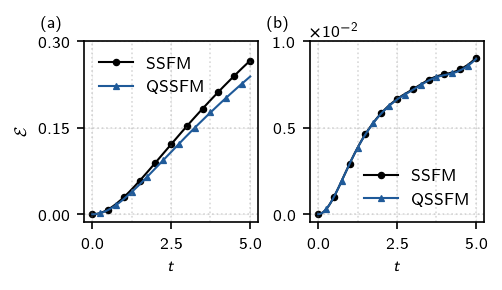

In [ ]:

width = 8.6 / 2.54
height = width * 0.6


light_blue = '#AFCDEA'
mid_blue   = "#429ad9"
dark_blue  = '#1F5A99'


def add_reference_lines(ax, h_values, v_values,
                        color='0.5', linestyle=':',
                        linewidth=0.8, alpha=0.3):

    for y in h_values:
        ax.axhline(y, linestyle=linestyle, linewidth=linewidth,
                   color=color, alpha=alpha)
    for x in v_values:
        ax.axvline(x, linestyle=linestyle, linewidth=linewidth,
                   color=color, alpha=alpha)


def style_axis(ax, xlabel, ylabel=None,
               xticks=None, yticks=None,
               label_fontsize=fontsize,
               tick_fontsize=fontsize,
               y_sci=False,
               sci_powerlimits=(-2, 2)):

    ax.grid(True, which='both',
            linestyle='--',
            linewidth=0.5,
            color='0.8',
            alpha=0.3)

    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=label_fontsize)

    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)

    ax.tick_params(axis='both', labelsize=tick_fontsize)

    if y_sci:
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits(sci_powerlimits)
        ax.yaxis.set_major_formatter(formatter)
        ax.ticklabel_format(axis='y', style='sci', scilimits=sci_powerlimits)
def add_panel_label(ax, label, x=-0.25, y=1.15, fontsize=8):

    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=fontsize,
        va='top', ha='left'
    )


def plot_lines(ax, x, line_specs):

    for spec in line_specs:
        ax.plot(
            x,
            spec['y'],
            color=spec.get('color', 'k'),
            linewidth=spec.get('linewidth', 1.0),
            linestyle=spec.get('linestyle', '-'),
            label=spec.get('label', None),
            marker=spec.get('marker', None),
            markersize=spec.get('markersize', None),
            markevery=spec.get('markevery', None),
            markerfacecolor=spec.get('markerfacecolor', None),
            markeredgecolor=spec.get('markeredgecolor', None),
            markeredgewidth=spec.get('markeredgewidth', None),
        )

def setup_panel(ax, x, line_specs, panel_label,
                xlabel=r"$t$", ylabel=None,
                xticks=None, yticks=None,
                hline_values=None, vline_values=None,
                legend=True,
                y_sci=False,
                sci_powerlimits=(-2, 2)):

    plot_lines(ax, x, line_specs)

    style_axis(
        ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xticks=xticks,
        yticks=yticks,
        y_sci=y_sci,
        sci_powerlimits=sci_powerlimits
    )

    if hline_values is not None or vline_values is not None:
        add_reference_lines(
            ax,
            h_values=[] if hline_values is None else hline_values,
            v_values=[] if vline_values is None else vline_values
        )

    if legend:
        ax.legend(frameon=False, fontsize=fontsize)

    add_panel_label(ax, panel_label)




panel_configs = [
    {
        "x": t1,
        "line_specs": [
            {"y": qssfmn3, "color": "black", "linewidth": 1, "label": r"SSFM",
                "marker": "o",
                "markersize": 3,
                "markevery":  50,
                "markerfacecolor": "black",
                "markeredgecolor": "black",
                "markeredgewidth": 0.6},
            {"y": qssfm_with_normn3,
                "color": dark_blue,
                "linewidth": 1,
                "label": r"QSSFM",
                "marker": "^",
                "markersize": 3,
                "markevery": (25, 50),
                "markerfacecolor": dark_blue,
                "markeredgecolor": dark_blue,
                "markeredgewidth": 0.6},
        ],
        "panel_label": "(a)", 
        "xlabel": "$t$",
        "ylabel": r"$\mathcal{E}$",
        "xticks": np.linspace(0, 5, 3),
        "yticks": np.linspace(0, 0.3, 3),
        "hline_values": np.linspace(0, 0.3, 3),
        "vline_values": np.linspace(0, 5, 5),
        "legend": True,
    },
    {
        "x": t1,
        "line_specs": [
            {"y": qssfm, "color": "black", "linewidth": 1, "label": r"SSFM",
                "marker": "o",
                "markersize": 3,
                "markevery":  50,
                "markerfacecolor": "black",
                "markeredgecolor": "black",
                "markeredgewidth": 0.6},
            {"y": qssfm_with_norm,
                "color": dark_blue,
                "linewidth": 1,
                "label": r"QSSFM",
                "marker": "^",
                "markersize": 3,
                "markevery": (25, 50),
                "markerfacecolor": dark_blue,
                "markeredgecolor": dark_blue,
                "markeredgewidth": 0.6},
        ],
        "panel_label": "(b)", 
        "xlabel": "$t$",
        "ylabel": None,
        "xticks": np.linspace(0, 5, 3),
        "yticks": np.linspace(0, 0.01, 3),
        "hline_values": np.linspace(0, 0.01, 3),
        "vline_values": np.linspace(0, 5, 5),
        "legend": True,
        "y_sci": True,
    },

]


def main():
    fig, axes = plt.subplots(1, 2, figsize=(width, height))

  
    for ax, cfg in zip(axes.flat, panel_configs): 
        setup_panel(
            ax=ax,
            x=cfg["x"],
            line_specs=cfg["line_specs"],
            panel_label=cfg["panel_label"],
            xlabel=cfg["xlabel"],
            ylabel=cfg["ylabel"],
            xticks=cfg["xticks"],
            yticks=cfg["yticks"],
            hline_values=cfg["hline_values"],
            vline_values=cfg["vline_values"],
            legend=cfg["legend"],
            y_sci=cfg.get("y_sci", False),
            sci_powerlimits=cfg.get("sci_powerlimits", (-2, 2)),
        )

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    plt.savefig("error_m=3_m=4.pdf", dpi=300,bbox_inches="tight", pad_inches=0.02)
    # plt.show()


if __name__ == "__main__":
    main()